In [211]:
# import libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [212]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [213]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [214]:
# # Replace inf values and Fill nan values
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.fillna(df.mean(), inplace=True)

# df

In [215]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [216]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [217]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [218]:
# view head of data frame
df.head(10)

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-01-31,0.072035,7.645292,67.428589,1.543070,125.413544,113.610780
2015-02-28,0.006426,8.922378,70.650015,2.028034,141.317670,140.054435
2015-03-31,0.077839,13.563225,76.834435,1.660385,143.476980,174.070484
2015-04-30,0.081847,19.224128,73.753208,2.032741,164.605403,206.481750
2015-05-31,0.294976,21.677381,81.306694,2.196621,165.946011,195.665538
2015-06-30,0.078669,24.955110,74.396847,1.750360,183.299560,277.447944
2015-07-31,0.037898,27.383618,63.137110,2.276917,188.493058,312.588132
2015-08-31,0.001366,28.382122,55.145027,1.689995,178.802012,277.001452
2015-09-30,0.011994,25.864828,58.636056,1.556549,164.779677,236.575625


In [219]:
# Verify shape of data frame
df.shape

(72, 6)

## Visualization 

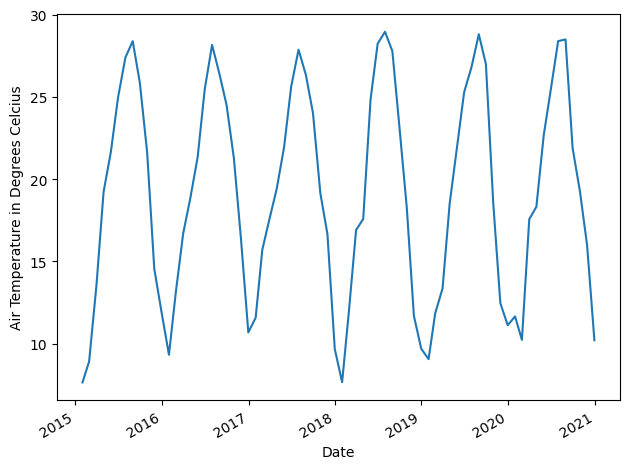

In [220]:
# Visualize Tair Montly Data for 2015
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature in Degrees Celcius')


fig.autofmt_xdate()
plt.tight_layout()



## Exploration 

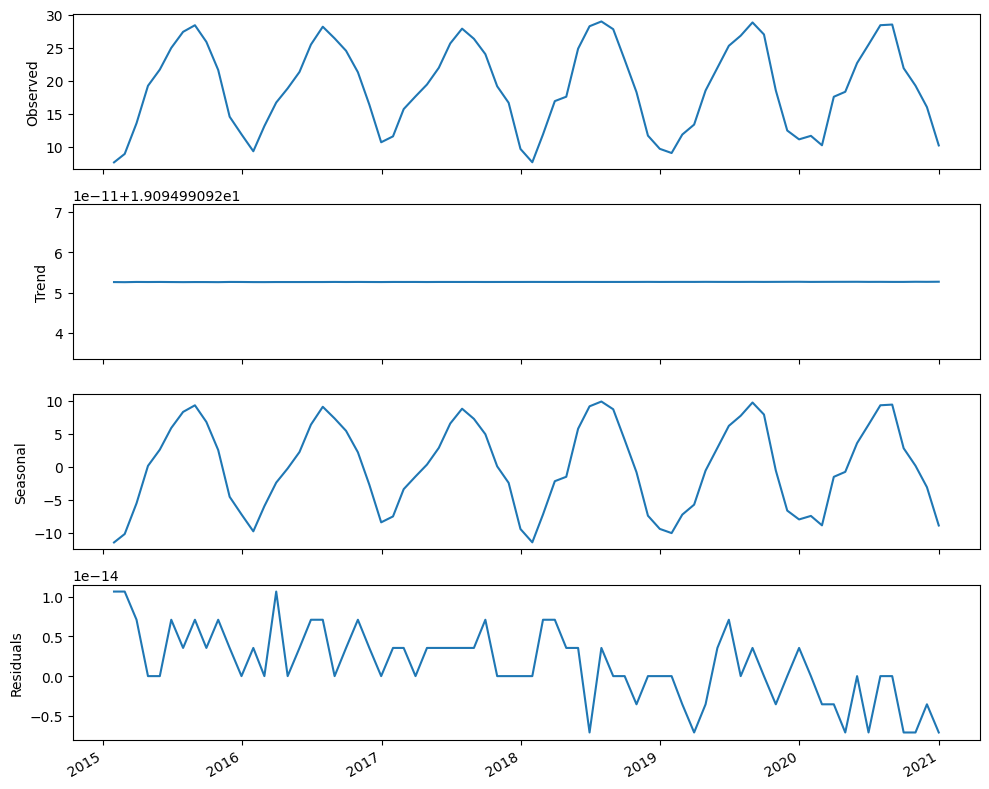

In [297]:
# Decompose data  to view seasonality, trend, and residuals
decomposition = STL(df.Tair, period=72).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')


fig.autofmt_xdate()
plt.tight_layout()



## Modeling 

In [222]:
# Preform Ad Fuller Test to check for stationarity
ad_fuller_result = adfuller(df.Tair)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.2204003571452113
p-value: 0.1989247896799317


In [223]:
# Difference Data and check Ad Fuller test again
Tair_diff = np.diff(df.Tair, n=1)

ad_fuller_result = adfuller(Tair_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -3.8246672401047315
p-value: 0.002664783490495973


### Train/test split 

In [225]:
# split data into train and test
train_len = 60
test_len = 12
total_len = 72

train = df.Tair[:train_len]
test = df.Tair[train_len:]

test

Date
2020-01-31    11.656753
2020-02-29    10.230040
2020-03-31    17.565515
2020-04-30    18.316893
2020-05-31    22.660909
2020-06-30    25.450068
2020-07-31    28.385785
2020-08-31    28.487495
2020-09-30    21.889972
2020-10-31    19.245260
2020-11-30    16.001203
2020-12-31    10.208196
Freq: M, Name: Tair, dtype: float64

In [305]:
# incorperate exog data
exog = df.Srad[:train_len]

exog_full = np.empty([72, 5])
exog_full[:, 0] = df.Ppt
exog_full[:, 1] = df.RH
exog_full[:, 2] = df.Windspeed
exog_full[:, 3] = df.Winddirection
exog_full[:, 4] = df.Srad


# exog_full= exog_full.drop('Tair', axis=1)

### SARIMA(p,0,q)(P,0,Q)<sub>12<sub> 

In [226]:
# Define SARIMA model
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [270]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12

In [308]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(train, exog, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), 307.72735416943493]
[(0, 0, 0, 1), 285.91616076243116]
[(0, 0, 1, 0), 275.09029176413696]
[(0, 0, 1, 1), 274.7238306429936]
[(0, 1, 0, 0), 279.702950162343]
[(0, 1, 0, 1), 267.227841542329]
[(0, 1, 1, 0), 259.90553809351877]
[(0, 1, 1, 1), 258.8833346491606]
[(1, 0, 0, 0), 291.83399121510115]
[(1, 0, 0, 1), 278.31953664454136]
[(1, 0, 1, 0), 271.15202491421974]
[(1, 0, 1, 1), 262.77316423599046]
[(1, 1, 0, 0), 281.6904411511914]
[(1, 1, 0, 1), 268.20913101475344]
[(1, 1, 1, 0), 260.3391105895305]
[(1, 1, 1, 1), 262.0537146756344]


,"(p,q,P,Q)",AIC
0,"(0, 1, 1, 1)",258.883335
1,"(0, 1, 1, 0)",259.905538
2,"(1, 1, 1, 0)",260.339111
3,"(1, 1, 1, 1)",262.053715
4,"(1, 0, 1, 1)",262.773164
5,"(0, 1, 0, 1)",267.227842
6,"(1, 1, 0, 1)",268.209131
7,"(1, 0, 1, 0)",271.152025
8,"(0, 0, 1, 1)",274.723831
9,"(0, 0, 1, 0)",275.090292


In [307]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], total_len), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               Tair   No. Observations:                   60
Model:             SARIMAX(0, 0, 1)x(1, 0, 1, 72)   Log Likelihood                   0.000
Date:                            Wed, 05 Jul 2023   AIC                              8.000
Time:                                    18:40:26   BIC                                nan
Sample:                                01-31-2015   HQIC                               nan
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1               0         -0        nan        nan           0           0
ar.S.L72            0         -0   

## Forecasting 

In [282]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
        
        
        for i in range(train_len, total_len, window):
            last_season = df.Tair[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.Tair[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 12), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [283]:
pred_df = df[train_len:]

pred_df

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2020-01-31,0.074763,11.656753,70.678777,1.769093,172.654038,117.010901
2020-02-29,0.051457,10.230040,71.040733,1.931305,146.350635,144.192227
2020-03-31,0.105487,17.565515,78.742460,1.946122,165.829680,147.392204
2020-04-30,0.114303,18.316893,70.896958,1.777963,154.481067,220.948694
2020-05-31,0.209957,22.660909,70.565860,1.869457,163.343905,267.534691
2020-06-30,0.020461,25.450068,68.773917,1.892825,172.586390,288.940472
2020-07-31,0.012632,28.385785,63.380806,1.911239,179.631645,289.584073
2020-08-31,0.009218,28.487495,56.992675,1.668910,175.461543,278.116263
2020-09-30,0.198264,21.889972,78.318292,1.350307,135.840933,180.323375


In [284]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len / 3)

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.last_season

Date
2020-01-31    26.984912
2020-02-29    18.533940
2020-03-31    12.459656
2020-04-30    11.124320
2020-05-31    11.656753
2020-06-30    10.230040
2020-07-31    17.565515
2020-08-31    18.316893
2020-09-30    22.660909
2020-10-31    25.450068
2020-11-30    28.385785
2020-12-31    28.487495
Freq: M, Name: last_season, dtype: float64

In [285]:
# Define SARIMA Prediction Dataframe
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

Date
2020-01-31    11.609967
2020-02-29    12.173972
2020-03-31    15.437298
2020-04-30    18.491057
2020-05-31    21.626504
2020-06-30    25.897643
2020-07-31    27.724521
2020-08-31    27.559567
2020-09-30    25.147559
2020-10-31    19.419218
2020-11-30    13.945124
2020-12-31    10.502657
Freq: M, Name: SARIMA, dtype: float64

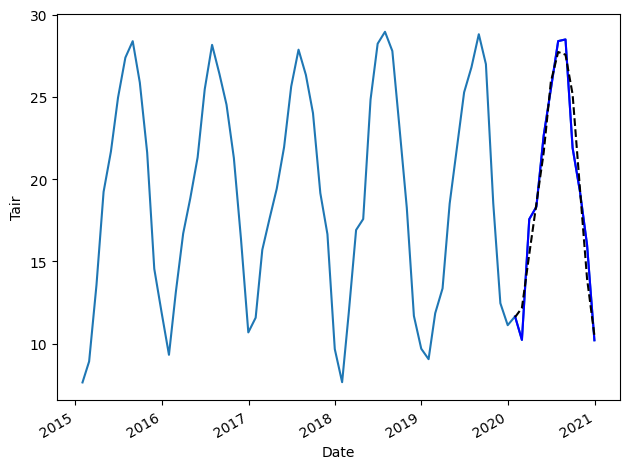

In [286]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.plot(pred_df.Tair, 'b-', label='actual')
# ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Tair')

fig.autofmt_xdate()
plt.tight_layout()



## Evaluate 

In [287]:
mse=np.mean((pred_df.Tair-pred_df.SARIMA)**2)
mse

2.1554697364639313